# Mathematische OSS in der Praxis
## Logik, Optimierung, Graphentheorie und mehr mit SageMath

**Manfred Scheucher**  
Grazer Linuxtage 2026

## Überblick

SageMath ist ein **open source Computer-Algebra-System** (Python-basiert).

Heute: Einblick in verschiedene Bereiche — jeweils mit kleinen Live-Beispielen.

| Bereich | Topics |
|---|---|
| **Analysis** | symbolisch, numerisch, Ableitungen, Integrale, Plots |
| **Algebra** | Gleichungssysteme, Ringe, Körper, Gruppen |
| **Geometrie** | 2D Arrangements, 3D Polyeder |
| **Graphentheorie** | Färbung, kürzeste Wege, Algorithmen |
| **Optimierung** | Mixed Integer Linear Programming (MILP) |
| **Logik** | SAT Solver |

---

**Wichtig:** Zu (fast) jedem Bereich gibt es mehrere Bibliotheken — auch open source.  
Sage kann oft zwischen verschiedenen Implementierungen/Backends wählen.

---
## Analysis

Sage arbeitet **symbolisch** — nicht nur numerisch.  
Das heißt: exakte Ergebnisse, keine Rundungsfehler.

In [1]:
x = var('x')
f = sin(x)

# Symbolische Ableitung
df = f.diff(x)
print("f(x)  =", f)
print("f'(x) =", df)

f(x)  = sin(x)
f'(x) = cos(x)


In [ ]:
# Symbolisches Integral
I = integrate(f, x, 0, pi/2)
print("∫ sin(x) dx von 0 bis π/2 =", I)

In [ ]:
# Plot: f blau, f' rot, Fläche unter Integral einzeichnen
p = plot(f, (x, 0, 2*pi), color='blue', legend_label='f(x) = sin(x)')
p += plot(df, (x, 0, 2*pi), color='red', legend_label="f'(x) = cos(x)")
p += plot(f, (x, 0, pi/2), color='blue', fill=True, fillcolor='lightblue', fillalpha=0.5)
p.show()

---
## Algebra

Symbolisches Lösen von Gleichungssystemen — auch geometrisch interpretierbar.

**Beispiel:** Zwei Kreise (Radius 2) — wo schneiden sie sich?

$$C_1: (x-1)^2 + y^2 = 4 \qquad C_2: (x+1)^2 + y^2 = 4$$

In [ ]:
x, y = var('x y')

C1 = (x-1)^2 + y^2 == 4
C2 = (x+1)^2 + y^2 == 4

solutions = solve([C1, C2], x, y)
print("Schnittpunkte (symbolisch):", solutions)
for s in solutions:
    xs, ys = s
    print(f"  x = {xs.rhs()},  y ≈ {float(ys.rhs()):.4f}")

In [ ]:
p = implicit_plot(C1.lhs() - C1.rhs(), (x, -4, 4), (y, -3, 3), color='blue')
p += implicit_plot(C2.lhs() - C2.rhs(), (x, -4, 4), (y, -3, 3), color='red')
for s in solutions:
    xs, ys = s
    p += point((float(xs.rhs()), float(ys.rhs())), size=50, color='black', zorder=5)
p.show(aspect_ratio=1)

---
## Geometrie

Sage kann 2D und 3D visualisieren — auch komplexe Strukturen mit wenig Code.

In [ ]:
import random
from scipy.spatial import Voronoi, ConvexHull

random.seed()  # system time
pts = [(random.uniform(0,1), random.uniform(0,1)) for _ in range(20)]

hull2d = ConvexHull(pts)
hull_indices = set(hull2d.vertices)

@interact
def geo_demo(mode=selector(['Nearest Neighbor', 'Voronoi', 'Convex Hull'], label='Modus')):
    inner = [pts[i] for i in range(len(pts)) if i not in hull_indices]
    outer = [pts[i] for i in hull_indices]

    p = points(inner, size=30, color='black')
    p += points(outer, size=30, color='blue')

    if mode == 'Nearest Neighbor':
        for i, (ax, ay) in enumerate(pts):
            best = min((j for j in range(len(pts)) if j != i),
                       key=lambda j: (pts[j][0]-ax)**2 + (pts[j][1]-ay)**2)
            bx, by = pts[best]
            p += arrow((ax, ay), (bx, by), color='blue', width=1, arrowsize=2)

    elif mode == 'Voronoi':
        vor = Voronoi(pts)
        for simplex in vor.ridge_vertices:
            if -1 not in simplex:
                x0, y0 = vor.vertices[simplex[0]]
                x1, y1 = vor.vertices[simplex[1]]
                p += line([(x0,y0),(x1,y1)], color='red')

    elif mode == 'Convex Hull':
        hull_pts = [pts[i] for i in hull2d.vertices] + [pts[hull2d.vertices[0]]]
        p += polygon(hull_pts, color='lightblue', alpha=0.5)
        p += line(hull_pts, color='blue', thickness=2)

    p.show(axes=False, frame=True, xmin=-0.05, xmax=1.05, ymin=-0.05, ymax=1.05)

In [ ]:
# 3D: Ikosaeder — 20 Flächen, 12 Ecken, wenig Code
I = polytopes.icosahedron()
print("Ecken:", len(I.vertices()))
print("Flächen:", len(I.faces(2)))
I.plot()

In [9]:
import random
from scipy.spatial import ConvexHull
import numpy as np

random.seed()  # system time
pts3 = [(random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1)) for _ in range(30)]
arr3 = np.array(pts3)

hull3 = ConvexHull(arr3)
hull_idx3 = set(hull3.vertices)

p3 = point3d([pts3[i] for i in hull_idx3], size=10, color='blue')
p3 += point3d([pts3[i] for i in range(len(pts3)) if i not in hull_idx3], size=10, color='black')

for simplex in hull3.simplices:
    tri = [pts3[i] for i in simplex]
    p3 += polygon3d(tri, color='lightblue', alpha=0.3)

p3.show()

Graphics3d Object

### 3D Pseudohyperebenen-Arrangement

- [helenabergold.github.io/supp/3d_signotopes](https://helenabergold.github.io/supp/3d_signotopes/index.html)
- [arxiv.org/abs/2303.04079](https://arxiv.org/abs/2303.04079) — Signotopes

### 2D Pseudokreis-Arrangement

[IPE Drawing Editor](https://ipe.otfried.org/)

![arrangement](figs/arrangement.png)

![krupp](figs/Krupp.png)

Flächen → Knoten, Nachbarschaft → Kanten

- [arxiv.org/abs/1708.06449](https://arxiv.org/abs/1708.06449) — Triangles and Drawings
- [arxiv.org/abs/1712.02149](https://arxiv.org/abs/1712.02149) — Circularizability

In [ ]:
from IPython.display import display, HTML

with open('lasagne3d/example_pshyperplanes.html', 'r') as f:
    html_content = f.read()

display(HTML(f'<div style="width:900px; height:600px; overflow:hidden">{html_content}</div>'))

---
## Graphentheorie

Sage hat eine eigene native Graphbibliothek (Cython/C-Backend).  
Optional: Schnittstellen zu **Boost Graph Library** (C++) und **NetworkX** (Python).

```python
G.networkx_graph()   # Konvertierung zu NetworkX
# Boost: sage.graphs.boost_graph (Cython-Wrapper, z.B. für Dijkstra)
```

Knoten: ['A', 'B', 'C', 'D', 'E', 'F']
Kanten: [('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F')]


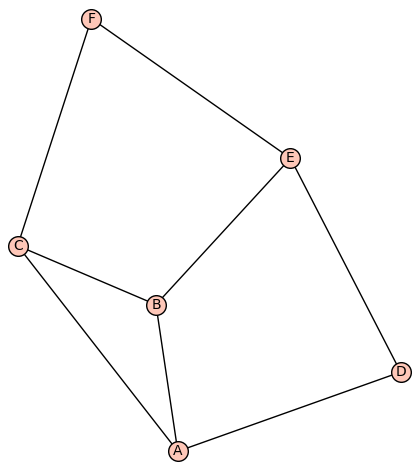

In [9]:
# Graph definieren und plotten
G = Graph({'A': ['B','C','D'], 'B': ['C','E'], 'C': ['F'], 'D': ['E'], 'E': ['F'], 'F': []})
print("Knoten:", G.vertices())
print("Kanten:", G.edges(labels=False))
G.plot()

Chromatische Zahl: 3
Färbung: [['A', 'E'], ['B', 'D', 'F'], ['C']]


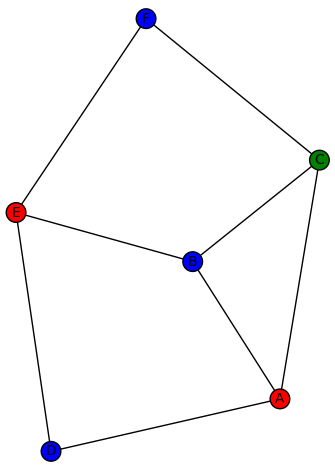

In [10]:
# Graphfärbung
chi = G.chromatic_number()
print("Chromatische Zahl:", chi)

coloring = G.coloring()
print("Färbung:", coloring)

G.plot(vertex_colors={
    'red':   coloring[0],
    'blue':  coloring[1],
    'green': coloring[2] if len(coloring) > 2 else []
})

In [11]:
# Kürzeste Wege — Floyd-Warshall (paarweise Distanzmatrix)
D = G.distance_all_pairs()
vertices = sorted(G.vertices())

print("Distanzmatrix (Floyd-Warshall):")
header = "    " + "  ".join(f"{v:>3}" for v in vertices)
print(header)
for u in vertices:
    row = f"{u:>3} " + "  ".join(f"{D[u][v]:>3}" for v in vertices)
    print(row)

Distanzmatrix (Floyd-Warshall):
      A    B    C    D    E    F
  A   0    1    1    1    2    2
  B   1    0    1    2    1    2
  C   1    1    0    2    2    1
  D   1    2    2    0    1    2
  E   2    1    2    1    0    1
  F   2    2    1    2    1    0


### Graphbibliotheken — Ökosystem

| Bibliothek | Sprache | Stärken |
|---|---|---|
| **SageMath** | Python/Cython | CAS-Integration, exakte Algorithmen |
| **NetworkX** | Python | Einfach, viele Algorithmen, gute Docs |
| **Boost Graph Library** | C++ | Performance, Teil von Boost |

SageMath kann zu NetworkX konvertieren und nutzt Boost intern optional als Backend.

---
## Mixed Integer Linear Programming (MILP)

**"Programmierung"** hier = abstraktes mathematisches Konzept (wie auch "dynamische Programmierung") — keine Programmiersprache.

### Modell: Gewinnmaximierung im Stall

Variablen: $x_1$ = Schweine, $x_2$ = Hühner, $x_3$ = Kühe — jeweils **ganzzahlig, nicht-negativ**.

$$\max \; 30 x_1 + 5 x_2 + 50 x_3$$

$$\text{s.t.} \quad
\underbrace{50 x_1 + 10 x_2 + 200 x_3}_{\text{Wasser (L/Tag)}} \leq 1000$$

$$\underbrace{3 x_1 + 0.5 x_2 + 8 x_3}_{\text{Futter (kg/Tag)}} \leq 40$$

$$\underbrace{x_1 + x_2 + x_3}_{\text{Stallplätze}} \leq 12$$

$$x_1, x_2, x_3 \in \mathbb{Z}_{\geq 0}$$

Modellierung oft **straight-forward** — aber: Encoding-Entscheidungen können Solver-Laufzeit drastisch beeinflussen.

In [ ]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(integer=True, nonnegative=True)

p.set_objective(30*x[1] + 5*x[2] + 50*x[3])          # max Profit (€)

p.add_constraint(50*x[1] + 10*x[2] + 200*x[3] <= 1000)  # Wasser (L/Tag)
p.add_constraint( 3*x[1] +  0.5*x[2] +  8*x[3] <= 40)   # Futter (kg/Tag)
p.add_constraint(   x[1] +    x[2] +    x[3] <= 12)      # Stallplätze

p.solve()

print(f"Schweine: {int(p.get_values(x[1]))}")
print(f"Hühner:   {int(p.get_values(x[2]))}")
print(f"Kühe:     {int(p.get_values(x[3]))}")
print(f"Profit:   € {int(p.get_values(30*x[1] + 5*x[2] + 50*x[3]))}")

### Encoding & Solver-Effizienz

- Modellierung oft **straight-forward** — aber Encoding-Entscheidungen können Laufzeit **drastisch** beeinflussen
- Wenige Variablen & Constraints = gut; aber: Hilfsvariablen können Suchraum verkleinern
- **Symmetrien** im Suchraum werden von Solvern meist *nicht* erkannt → manuell brechen
- **Dualität**: Maximierungsproblem ↔ äquivalentes Minimierungsproblem
- SAT ist Spezialfall von MILP (nur 0/1-Variablen, Constraints als Summe ≥ 1)

---
## SAT Solver

**Hinweis:** Die SAT-Solver-Implementierungen in Sage sind veraltet (PicoSAT etc.) und nicht mehr zeitgemäß — aktuelle Solver sind CaDiCaL, Kissat, Glucose.

Wir verwenden stattdessen **pysat** — einfach installierbar, gleiche Syntax, aktuelle Solver:

```
pip install python-sat
```

In [ ]:
# pip install python-sat
from pysat.solvers import Cadical195

# Formel: (x1 ∨ x2) ∧ (¬x1 ∨ x3) ∧ (¬x2 ∨ ¬x3)
cnf = [
    [1, 2],    # x1 oder x2
    [-1, 3],   # nicht x1 oder x3
    [-2, -3],  # nicht x2 oder nicht x3
]

solver = Cadical195(bootstrap_with=cnf)
for model in solver.enum_models():
    print(model)

---
## Komplexität & NP

**Häufiges Missverständnis:** NP ≠ "nicht-polynomiell"

NP = **N**ichtdeterministisch **P**olynomiell  
→ bisher kein deterministischer Poly-Algorithmus gefunden, aber P=NP nicht ausgeschlossen!

### Überraschungen der letzten Jahrzehnte

- **Primfaktorisierung**: lange als "quadrathart" eingeschätzt → General Number Field Sieve (GNFS): subexponentiell
- **Graphisomorphie**: lange offen → Babai 2015: quasipolynomiell
- **3SUM**: jahrzehntelang als $\Theta(n^2)$-hart bezeichnet → 2014: $O(n^2 \log\log n / \log n)$

---

Falls die besten Tools nicht durchkommen: manchmal hilft es zu wissen, dass ein Problem **NP-schwer** ist —  
dann MILP/SAT einsetzen statt selbst "Zähne ausbeißen".

### Approximation

Wenn exakt zu teuer: **Approximationsalgorithmen** — für reale Anwendungen oft gut genug.

- **Traveling Salesman (TSP)**: NP-schwer, auch euklidisch — aber $(1+\varepsilon)$-Approximation in Polynomialzeit möglich

### Dynamische Programmierung

Auch "Programmierung" = abstraktes Konzept (keine Sprache).

**Kürzeste Wege** (Rekursion): Weg von $u$ nach $v$ über Nachbarn $w$:
$$d(u,v) = \min_{w \sim v} \bigl( d(u,w) + \text{weight}(w,v) \bigr)$$
Wenn kürzeste Wege zu allen Nachbarn bekannt → optimal kombinieren.

---
## Weiterführende Topics

Was heute nicht dran kam — aber in Sage (und drumherum) verfügbar:

| Topic | Tool/Library | Links |
|---|---|---|
| **SMT Solver** | Z3 (via Python) | https://ericpony.github.io/z3py-tutorial |
| **Zahlentheorie** | Sage nativ | Primzahlen, elliptische Kurven, ... |
| **Gruppentheorie** | Sage / GAP (Backend) | Permutationsgruppen, Charaktertafeln |
| **Formale Verifikation** | Lean, Coq | Beweise maschinell verifizieren |
| **Quantified Boolean Formula** | QCIR, QBF-Solver | https://wikipedia.org/wiki/QBF |
| **Answer Set Programming** | clingo/ASP | https://wikipedia.org/wiki/Answer_set_programming |
| **#SAT / Model Counting** | SharpSAT, ApproxMC | Lösungen zählen statt finden |

---

**Danke!**  
Fragen? Code & Notebook: *(Link folgt)*